# L2: LLM Inference Fundamentals

In this notebook, you'll build a working understanding of how LLMs generate text token by token — and why KV cache cuts the computational work from quadratic to linear.

## 📋 Learning Objectives

1. **Tokenization** — See how text maps to token IDs, the model's actual input
2. **Autoregressive generation** — Implement the decode loop from scratch
3. **Attention mechanism** — Translate the Q·K^T / √d_k formula directly into code
4. **KV cache** — Measure the speedup from caching Keys and Values across decode steps

## 1. Setup

Standard imports — PyTorch, our model wrapper, and two decode functions we'll compare: one without caching, one with.

<div style="background-color: #f5f9ff; padding: 15px; border-left: 4px solid #1565c0; border-radius: 5px; margin: 10px 0;">

📂 Helper functions can be found at: `SC-RadixArk-SGLang-C1/L2/helper.py`

`helper.py` provides the inference primitives used throughout this notebook: a model wrapper around DeepSeek-R1-Distill-Qwen, two decode loops (naive recompute vs. KV cache), and a custom attention implementation that translates the `Q·K^T / √d_k` formula directly into code.

</div>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import torch
import torch.nn.functional as F
from torch import Tensor

from helper import (
    TinyLLM,
    sample,
    auto_regressive_decode,
    auto_regressive_decode_with_kv_cache,
    demo_tokenization,
)

In [2]:
model_path = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
input_text = "SGLang is a fast inference engine for"
max_new_tokens = 16

## 2. Load Model

DeepSeek-R1-Distill-Qwen, 1.5B parameters. Small model, but the attention mechanics are identical to a 70B model — everything we learn here applies at any scale.

Note: You can see the full code for the TinyLLM model at L2/tiny_llm.py

In [3]:
tiny_llm = TinyLLM(model_path)

## 3. Baseline Generation

HuggingFace's built-in `generate()` uses KV cache by default. We run it first to get the reference output — everything we build must match this exactly.

You'll use this to verify that caching doesn't change what the model produces, only how efficiently it gets there.


In [4]:
# Baseline: HuggingFace generate() with KV cache enabled by default
output_text_std = tiny_llm.generate_std(
    input_text, max_new_tokens, temperature=0
)

print(f"Input:  \"{input_text}\"")
print(f"Output: \"{output_text_std}\"")
print(
    "\nThis is our ground truth"
    " — every implementation must match this exactly."
)

Input:  "SGLang is a fast inference engine for"
Output: "SGLang is a fast inference engine for SGMCMC samplers, which is designed to handle high-dimensional problems."

This is our ground truth — every implementation must match this exactly.


## 4. Tokenization

What does the model actually see as input? The tokenizer splits text into subword units, not whole words. Note how many input tokens we get — that number comes back when we count operations.

In [5]:
# See how the tokenizer splits our input into subword units
token_ids = demo_tokenization(tiny_llm, input_text)
initial_tokens = len(token_ids)
print(f"\n{initial_tokens} input tokens — remember this number for later.")

Tokenization Progress:
Token ID: 151646: "<｜begin▁of▁sentence｜>"
Token ID:     50: "S"
Token ID:   3825: "GL"
Token ID:    524: "ang"
Token ID:    374: " is"
Token ID:    264: " a"
Token ID:   4937: " fast"
Token ID:  44378: " inference"
Token ID:   4712: " engine"
Token ID:    369: " for"

10 input tokens — remember this number for later.


## 5. Custom Attention

In the slides, we saw the attention formula:    
**Attention(Q, K, V) = softmax(Q K^T / √d_k) · V**

Now we translate that formula directly into code:
- `_attention_impl`: The core computation — Q·K^T scaled, causal mask, softmax, multiply by V
- `simple_causal_attention`: A wrapper that handles **GQA** (Grouped Query Attention), where multiple query heads share the same K/V heads — this is how DeepSeek, Llama, and most modern models reduce KV cache memory

In [6]:
def _attention_impl(
    q: Tensor, k: Tensor, v: Tensor,
    scale: float, mask: Tensor
):
    """Core: softmax(Q @ K^T / sqrt(d_k)) @ V"""
    # Q @ K^T — attention scores for every (query, key) pair
    scores = torch.matmul(q, k.transpose(-2, -1)) * scale
    # Causal mask — future positions become -inf, then 0 after softmax
    scores = scores.masked_fill(~mask, float("-inf"))
    # Normalize to attention weights
    probs = torch.softmax(scores, dim=-1)
    # Weighted sum of values
    return torch.matmul(probs, v)

In [7]:
def simple_causal_attention(
    query: Tensor, key: Tensor, value: Tensor,
    **kwargs
):
    """Drop-in replacement for F.scaled_dot_product_attention
    with GQA support."""
    Dh = query.shape[-1]
    scale = 1.0 / (Dh**0.5)

    # GQA: multiple query heads share the same K/V heads
    gqa_group_size = query.shape[1] // key.shape[1]
    key = key.repeat_interleave(gqa_group_size, dim=1)
    value = value.repeat_interleave(gqa_group_size, dim=1)

    qf, kf, vf = query.float(), key.float(), value.float()

    # Causal mask: lower-triangular
    Tq, Tk = qf.shape[-2], kf.shape[-2]
    mask = torch.ones(
        (Tq, Tk), device=qf.device, dtype=torch.bool
    ).tril()
    mask = mask[None, None, :, :]

    out = _attention_impl(qf, kf, vf, scale, mask)
    return out.to(dtype=query.dtype)

We then **monkey-patch** PyTorch's `F.scaled_dot_product_attention` — that just means swapping out the function at runtime so every layer in the model runs our code instead of the built-in CUDA kernels. Slower, but lets us verify our math is correct.

In [8]:
# Swap PyTorch's attention with ours — every layer now runs our code
_orig_sdp = F.scaled_dot_product_attention
F.scaled_dot_product_attention = simple_causal_attention

tic = time.time()
text_monkey_patch = auto_regressive_decode(
    tiny_llm, input_text,
    max_new_tokens, temperature=0.0
)
toc = time.time()

# Restore original
F.scaled_dot_product_attention = _orig_sdp

print(f"Output: \"{text_monkey_patch}\"")
tok_per_sec = max_new_tokens / (toc - tic)
print(f"Time:   {toc - tic:.2f}s ({tok_per_sec:.1f} tok/s)")
match = text_monkey_patch == output_text_std
print(f"Match:  {'Yes' if match else 'MISMATCH!'}")

Output: "SGLang is a fast inference engine for SGMCMC samplers, which is designed to handle high-dimensional problems."
Time:   0.68s (23.6 tok/s)
Match:  Yes


## 6. KV Cache Comparison

Recall from the slides: K and V for a token depend only on that token — they never change once computed. So we have two phases:
- **Prefill**: process the full prompt in parallel, store all K and V
- **Decode**: generate one token at a time, but only the new token needs computation — all prior K and V come from cache

Let's measure the actual difference.

### Without KV Cache (naive)

This is the "without" case from the slides — every step feeds the entire sequence from scratch. Token "sat" recomputes "The" and "cat" even though their K and V haven't changed.

In [9]:
# Naive: recompute entire sequence from scratch at every step
tic = time.time()
text_no_cache = auto_regressive_decode(
    tiny_llm, input_text,
    max_new_tokens, temperature=0.0
)
toc = time.time()
time_no_cache = toc - tic

assert text_no_cache == output_text_std

# Total token computations:
# sum of (initial + 0), (initial + 1), ...,
#         (initial + max_new_tokens - 1)
total_ops = sum(
    initial_tokens + i for i in range(max_new_tokens)
)

print(f"Output: \"{text_no_cache}\"")
tok_s = max_new_tokens / time_no_cache
print(f"Time:   {time_no_cache:.2f}s ({tok_s:.1f} tok/s)")
print(f"Total token computations: {total_ops}")

Output: "SGLang is a fast inference engine for SGMCMC samplers, which is designed to handle high-dimensional problems."
Time:   0.66s (24.1 tok/s)
Total token computations: 280


### With KV Cache (optimized)

This is the "with" case from the slides — prefill stores K and V for all prompt tokens, then each decode step only processes the one new token. Same output, exact same math, just without the redundant work.

In [10]:
# Optimized: prefill once, then only process the new token each step
tic = time.time()
text_kv_cache = auto_regressive_decode_with_kv_cache(
    tiny_llm, input_text,
    max_new_tokens, temperature=0.0
)
toc = time.time()
time_with_cache = toc - tic

assert text_kv_cache == output_text_std

# prefill + one per decode step
total_ops_kv = initial_tokens + (max_new_tokens - 1)
speedup = time_no_cache / time_with_cache

print(f"Output: \"{text_kv_cache}\"")
tok_s = max_new_tokens / time_with_cache
print(f"Time:   {time_with_cache:.2f}s ({tok_s:.1f} tok/s)")
print(f"Total token computations: {total_ops_kv}")
print(f"\n--- Comparison ---")
print(
    f"Operations: {total_ops} \u2192 {total_ops_kv}"
    f" ({total_ops // total_ops_kv}x fewer)"
)
print(f"Speedup:    {speedup:.1f}x")

Output: "SGLang is a fast inference engine for SGMCMC samplers, which is designed to handle high-dimensional problems."
Time:   0.45s (35.6 tok/s)
Total token computations: 25

--- Comparison ---
Operations: 280 → 25 (11x fewer)
Speedup:    1.5x


### Visualization

The slides showed the conceptual difference — without cache, each step reprocesses the whole history; with cache, only the new token. Here's that same idea in numbers.

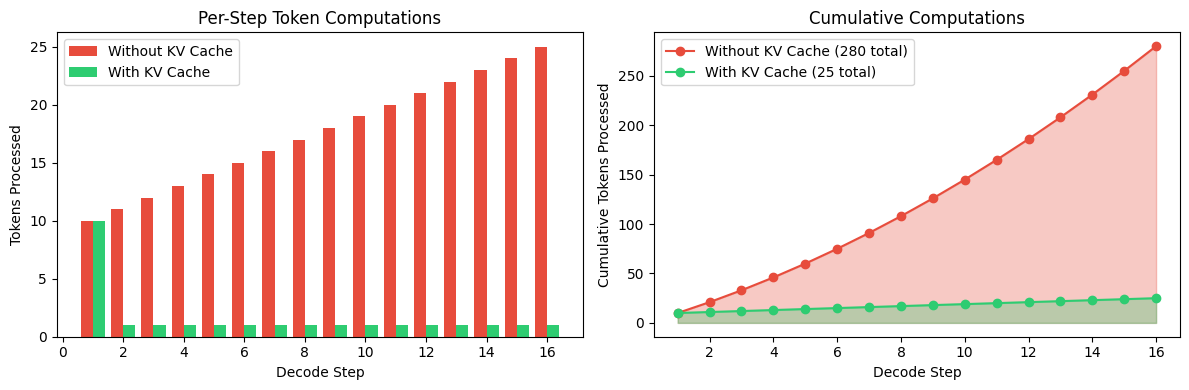

In [11]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(1, max_new_tokens + 1)
ops_no_cache = [initial_tokens + i for i in range(max_new_tokens)]
ops_kv_cache = [initial_tokens] + [1] * (max_new_tokens - 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Per-step comparison
ax1.bar(steps - 0.2, ops_no_cache, 0.4, label="Without KV Cache", color="#e74c3c")
ax1.bar(steps + 0.2, ops_kv_cache, 0.4, label="With KV Cache", color="#2ecc71")
ax1.set(xlabel="Decode Step", ylabel="Tokens Processed",title="Per-Step Token Computations")
ax1.legend()

# Cumulative comparison
ax2.fill_between(steps, np.cumsum(ops_no_cache), alpha=0.3, color="#e74c3c")
ax2.fill_between(steps, np.cumsum(ops_kv_cache), alpha=0.3, color="#2ecc71")
ax2.plot(steps, np.cumsum(ops_no_cache), "o-", color="#e74c3c",label=f"Without KV Cache ({total_ops} total)")
ax2.plot(steps, np.cumsum(ops_kv_cache), "o-",color="#2ecc71",label=f"With KV Cache ({total_ops_kv} total)")
ax2.set( xlabel="Decode Step", ylabel="Cumulative Tokens Processed",title="Cumulative Computations")
ax2.legend()
plt.tight_layout()
plt.show()

**Key takeaway:** KV cache computes Keys and Values once, stores them, reuses them. Work drops from quadratic to linear.

**Next lesson:** This helps within one request. What about across requests? Two users send the same system prompt — the model computes identical KV tensors twice. Lesson 3 fixes that with a radix tree that caches shared prefixes across requests.